In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


In [22]:
df = pd.read_csv(r"C:\Users\ramak\OneDrive\Desktop\CleanedData.csv")

Encode all categorical columns into numercic.


In [23]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})  
df['Job_Satisfaction_Level'] = df['Job_Satisfaction_Level'].map({'Low':1, 'Medium':2, 'High':3})
df['Promotion_in_Last_2_Years'] = df['Promotion_in_Last_2_Years'].map({'No':0, 'Yes':1})


In [24]:
X = df.drop(columns=['Attrition', 'Employee_ID'])
X = pd.get_dummies(X, columns=['Department'], drop_first=True)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
print(X.dtypes)


Age                          int64
Years_of_Experience          int64
Monthly_Working_Hours        int64
Training_Hours_per_Year      int64
Performance_Rating           int64
Job_Satisfaction_Level       int64
Promotion_in_Last_2_Years    int64
Department_Hr                 bool
Department_Operations         bool
Department_Sales              bool
Department_Tech               bool
dtype: object


In [26]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [27]:
print(X.dtypes)

Age                          int64
Years_of_Experience          int64
Monthly_Working_Hours        int64
Training_Hours_per_Year      int64
Performance_Rating           int64
Job_Satisfaction_Level       int64
Promotion_in_Last_2_Years    int64
Department_Hr                int64
Department_Operations        int64
Department_Sales             int64
Department_Tech              int64
dtype: object


In [28]:
rf_classifier = RandomForestClassifier(n_estimators=200,class_weight="balanced", random_state=42)
rf_classifier.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = rf_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8033333333333333
Precision: 0.5
Recall: 0.005649717514124294
F1-Score: 0.0111731843575419
Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89      1446
           1       0.50      0.01      0.01       354

    accuracy                           0.80      1800
   macro avg       0.65      0.50      0.45      1800
weighted avg       0.74      0.80      0.72      1800

Confusion Matrix:
 [[1444    2]
 [ 352    2]]


Accuracy ~ 80%
But Recall for class 1 is ~0.8 % .
Right now only about 20 % of employees have Attrition = Yes, so the Random Forest just keeps predicting “No” to stay accurate.

                      Feature  Importance
2       Monthly_Working_Hours    0.224504
3     Training_Hours_per_Year    0.194970
0                         Age    0.186631
1         Years_of_Experience    0.182937
4          Performance_Rating    0.073460
5      Job_Satisfaction_Level    0.049175
7               Department_Hr    0.018883
8       Department_Operations    0.017853
10            Department_Tech    0.017763
9            Department_Sales    0.016988
6   Promotion_in_Last_2_Years    0.016836


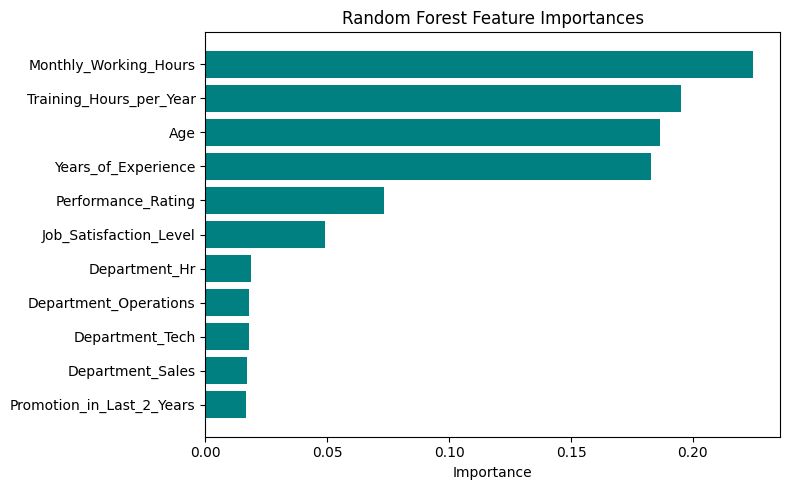

In [30]:
import matplotlib.pyplot as plt


importances = rf_classifier.feature_importances_
features   = X_train.columns


feat_imp = pd.DataFrame({'Feature': features,'Importance': importances}).sort_values(by='Importance', ascending=False)

print(feat_imp)   


plt.figure(figsize=(8,5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='teal')
plt.gca().invert_yaxis()  
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()
